Purpose: URL is Legitimate or Phising?

In [100]:
#Import necessary libraries with aliases
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
df = pd.read_csv("Phishing_URL_ds_5percent_missing.csv")
df.shape

(235795, 56)

Comment: Data has 235795 number of URL instances.

In [102]:
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31.0,NaN,24.0,0.0,com,100.0,1.000000,0.522907,...,0.0,0.0,1.0,34.0,20.0,NaN,119.0,0.0,124.0,1.0
1,31372.txt,https://www.uni-mainz.de,23.0,www.uni-mainz.de,16.0,0.0,NaN,100.0,0.666667,0.032650,...,0.0,0.0,1.0,50.0,9.0,8.0,39.0,0.0,217.0,1.0
2,597387.txt,https://www.voicefmradio.co.uk,NaN,www.voicefmradio.co.uk,22.0,0.0,uk,100.0,0.866667,0.028555,...,0.0,0.0,1.0,10.0,2.0,7.0,42.0,2.0,5.0,1.0
3,554095.txt,https://www.sfnmjournal.com,26.0,www.sfnmjournal.com,19.0,0.0,com,100.0,1.000000,0.522907,...,1.0,1.0,NaN,3.0,27.0,15.0,22.0,1.0,31.0,1.0
4,NaN,https://www.rewildingargentina.org,33.0,www.rewildingargentina.org,26.0,0.0,org,100.0,1.000000,0.079963,...,1.0,0.0,1.0,244.0,15.0,34.0,72.0,1.0,85.0,1.0


Comments: Data looks like clean in general.FILENAME seems unnecesarry column for our model. Looking more closely to data for missing data and datatypes.

In [103]:
#Removing FILENAME column, looking informations about columns
df = df.drop(df.columns[0], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         223935 non-null  object 
 1   URLLength                   223980 non-null  float64
 2   Domain                      224040 non-null  object 
 3   DomainLength                223911 non-null  float64
 4   IsDomainIP                  223820 non-null  float64
 5   TLD                         223927 non-null  object 
 6   URLSimilarityIndex          224026 non-null  float64
 7   CharContinuationRate        223894 non-null  float64
 8   TLDLegitimateProb           223989 non-null  float64
 9   URLCharProb                 224068 non-null  float64
 10  TLDLength                   223846 non-null  float64
 11  NoOfSubDomain               223980 non-null  float64
 12  HasObfuscation              224050 non-null  float64
 13  NoOfObfuscated

Comment: Column names seems consistent. We create missingness in data, as we can see there are missing values with different numbers in columns. Data types seems consistent with column meanings in general, there is no problem. For columns which have binary values should converted to the int data type. Reason behin this is mathematical rules, for library conformity in scikit-learn, and memory efficiency. Label is also should be converted. 

In [104]:
#Convert binary columns data type as int8/bool--bunu imputationdan sonra yapmalıyız. 

# #All features with numeric data types
# numeric_df = df.select_dtypes(include=['float64'])

# #Features have exactly 2 unique variables
# binary_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() == 2]

# #Features have more than 2 unique variables are not binary
# continuous_cols = [col for col in numeric_df.columns if numeric_df[col].nunique() > 2]

# print(f"Binary Feature Number: {len(binary_cols)}")
# print(f"Continous Feature Number: {len(continuous_cols)}")
# df[binary_cols] = df[binary_cols].astype('Int8')
# df.info()

In [105]:
#Checking duplicates
df[df.duplicated()]

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label


Comments: We have no duplicated observations. There is no problem. 

In [106]:
#Looking identical URLs
url_counts = df['URL'].value_counts()
print(url_counts)

URL
https://virginpaperagency.com/cgi/php/errore.php                        2
https://fb-restriction-case-9786a.firebaseapp.com/                      2
https://dev-home-seguridad-itau.pantheonsite.io/                        2
https://s42lkd.webwave.dev/lib/s42lkd/po-ldcuuw59.html                  2
https://marketingtechnologies.es/wp-admin/whidhet/f4db9c3b86f73456f/    2
                                                                       ..
https://topaka.cloud/ob52gtplj/18snwp                                   1
https://www.mlpack.org                                                  1
https://metafb-tvz6efk.web.app/                                         1
http://www.hesselawchambers.com                                         1
https://www.alternativefinland.com                                      1
Name: count, Length: 223548, dtype: int64


In [107]:
#Looking same url count number
print(len(url_counts[url_counts > 1]))

387


Comment: We have 387 URL names that seen twice in our dataset. This may cause data leakage. First question that comes to my mind is same url names have same label value?

In [108]:
#Looking url's with corresponding labels
inconsistent = df.groupby('URL')['label'].nunique()
print(inconsistent[inconsistent > 1])

Series([], Name: label, dtype: int64)


Comment: Although the URL names were the same, these URLs were not perceived differently as either phishing or legitimate. To avoid data leakage we remove same URL rows -> 387 rows from our dataset, other 387 with same value still in the dataset to use this informations in our model.

In [109]:
#Remove same url rows
df = df.drop_duplicates(subset=['URL'], keep='first')

#Test whether duplicate url's gone.
url_counts = df['URL'].value_counts()
print(len(url_counts[url_counts > 1]))

0


##Dealing with Label
0 represent phising and 1 represent legitimate URL is described in the UCL site. Our aim is detect the phising urls. In this case we calculate the legitiamte power. We should convert the target variables. At the final result we have 0 as legitimate URL, and 1 is phising URL. Target of interest must be 1.

In [110]:
print(df['label'].dtype)
print(df['label'].unique())
print(df['label'].isnull().sum())

float64
[ 1. nan  0.]
11161


In [111]:
print(df['label'].value_counts())
df['label'] = df['label'].map({0: 1, 1: 0})  #Otomatically change float to int. 
print(df['label'].value_counts())  #Int seems because of value counts, data stored still as float as you can see(0.0, 1.0)

label
1.0    121735
0.0     90653
Name: count, dtype: int64
label
0.0    121735
1.0     90653
Name: count, dtype: int64


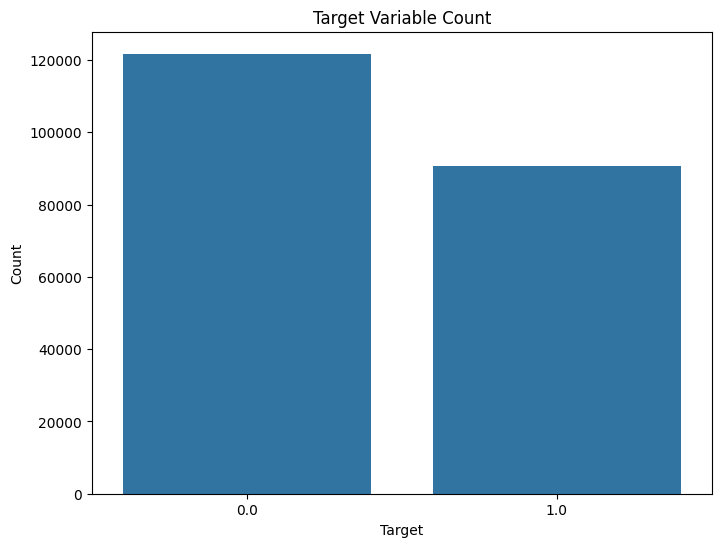

In [112]:
#Looking number of target variables. This is important for our problem. In real life most of the URL's are legitimate. 
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x=df["label"])
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Target Variable Count')
plt.show()

Comment: We see that the target variable counts are close to each other, a little bit imbalanced problem we deal with this. But as in real life scenario 0 (legitimate url) count is more than phising URL values. This dataset can gives us more information about phising urls. 

Firsly, we want to look at the correlation matrix in order to look at the which features have most effect on target variable. 

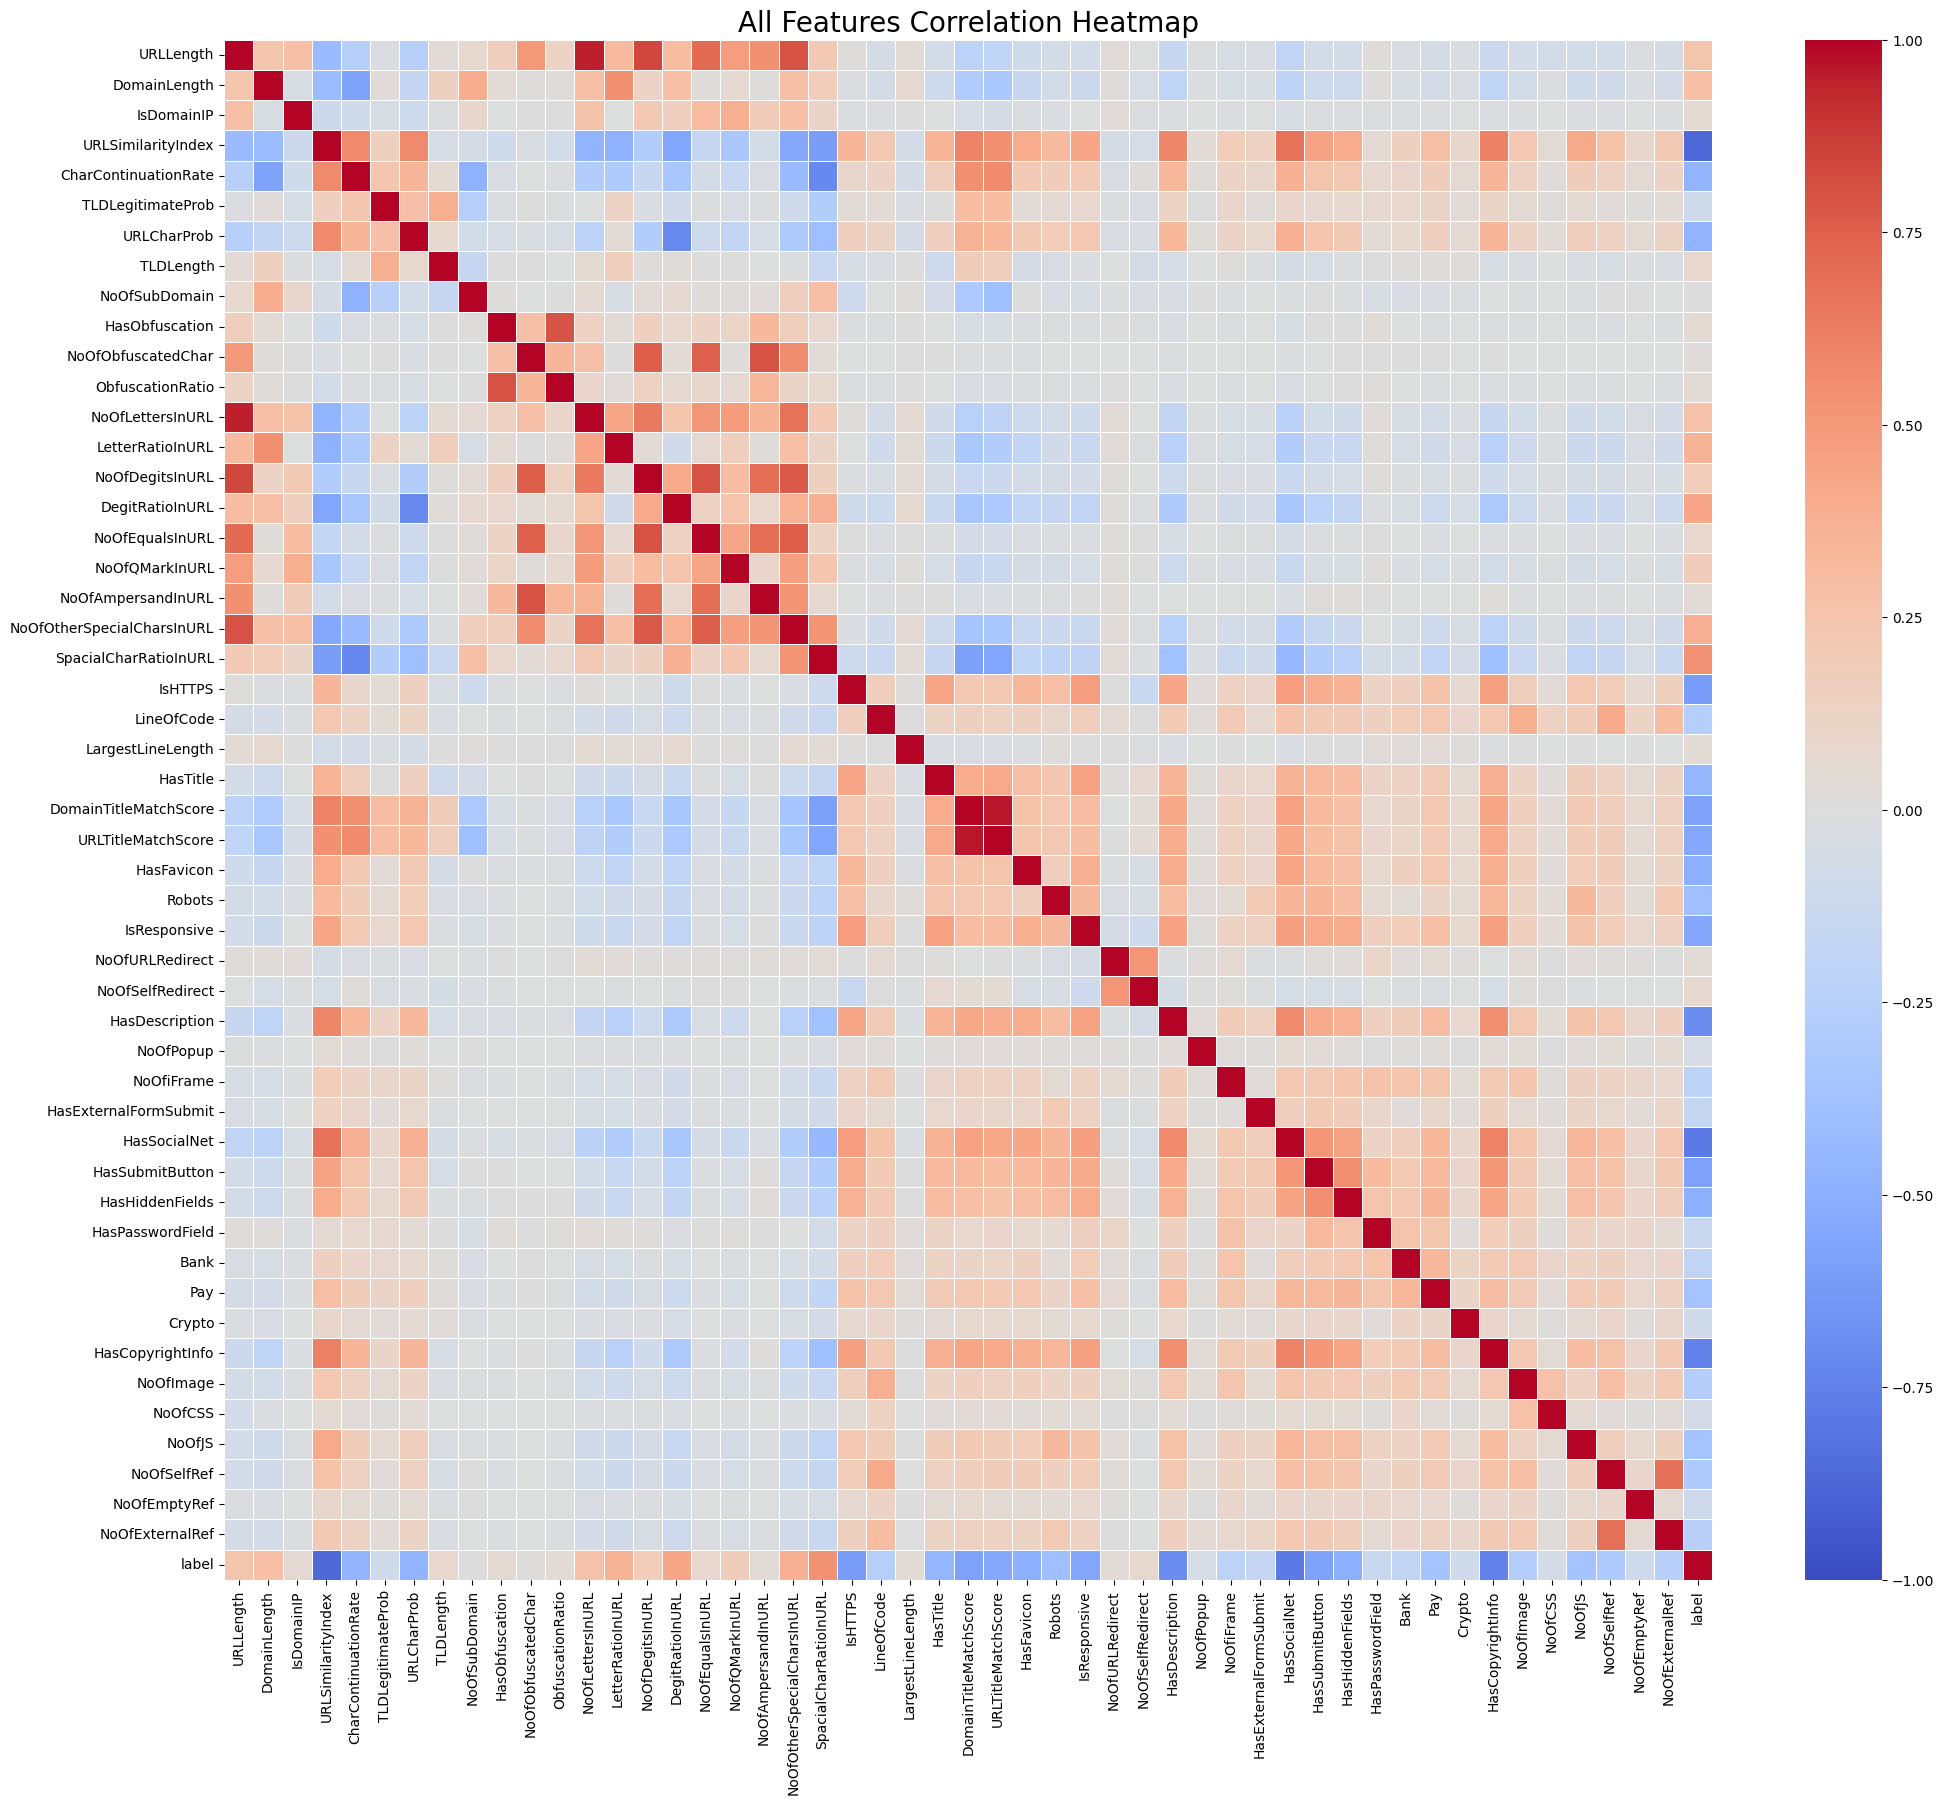

In [113]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(24, 20)) 
sns.heatmap(corr_matrix, 
            annot=False,      
            cmap='coolwarm',  # (Red: Positive, Blue: Negative)
            linewidths=0.5,   
            vmin=-1, vmax=1)

plt.title('All Features Correlation Heatmap', fontsize=20)
plt.show()

Comments: Strong correlation between features can be handle in feature enginerring part. Firstly, we want to look at closely on which features have effect on our target variable. We see this information on heatmap but we want to look closely.  

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11088\2732559188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)


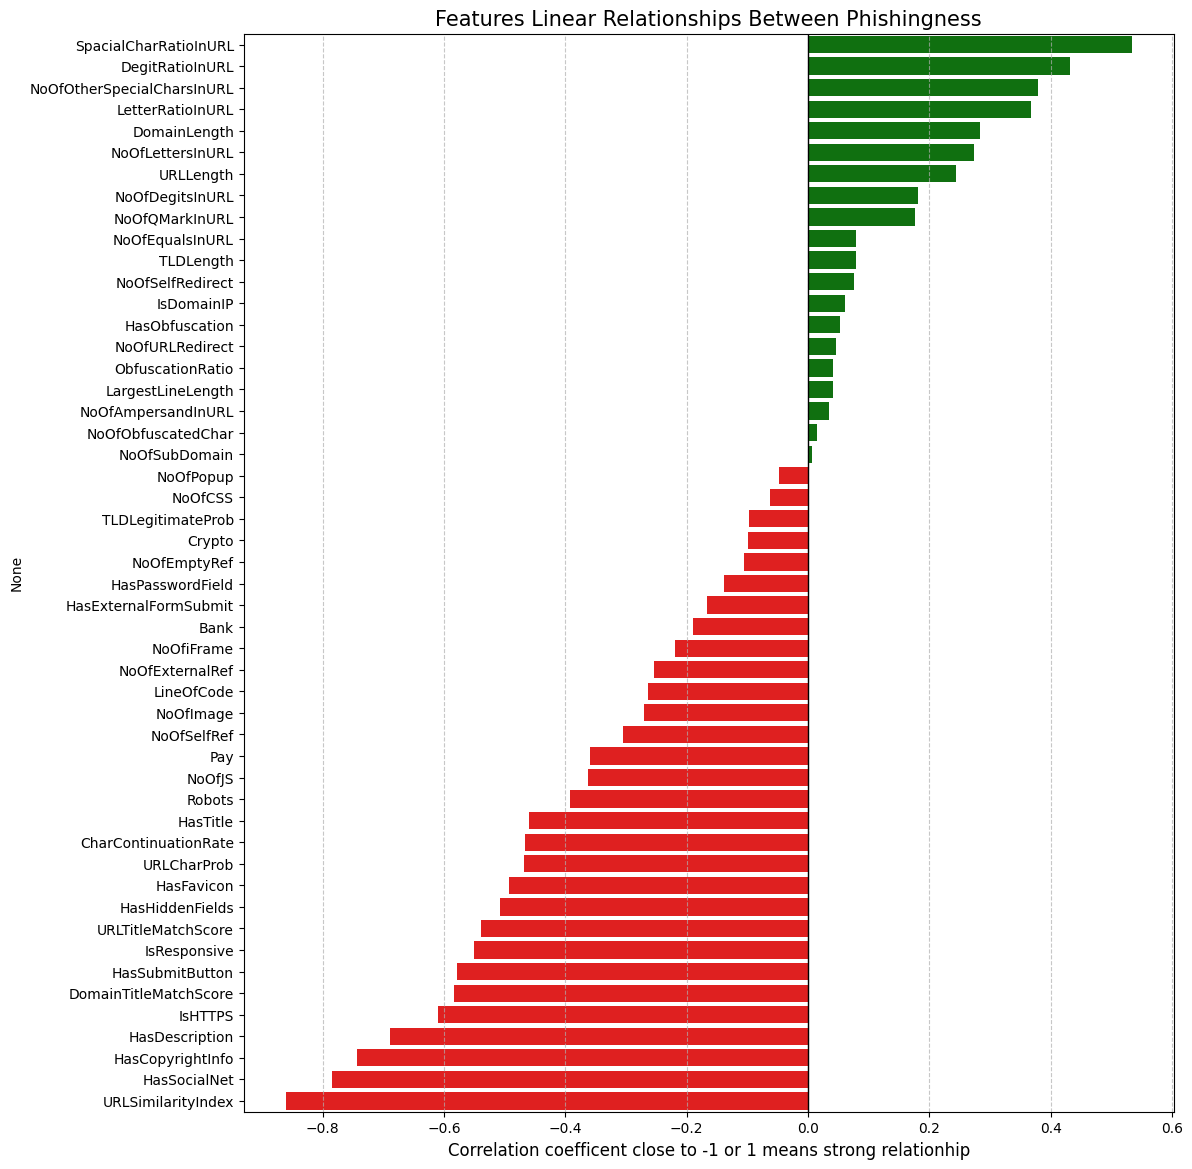

In [114]:
target_corr = numeric_df.corr()['label'].sort_values(ascending=False)
target_corr = target_corr.drop('label')
plt.figure(figsize=(12, 14))
colors = ['green' if x > 0 else 'red' for x in target_corr.values] # (Green:Positive, Red: Negative)
sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)

plt.title('Features Linear Relationships Between Phishingness', fontsize=15)
plt.xlabel('Correlation coefficent close to -1 or 1 means strong relationhip', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Black line in the middle
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Comment: Features that are close to 0 correlation coefficents indicates pottential features that we must deal with maybe we extract these from the model because they have not strong effect on target variable and adds complexity for our model. Strong relationships can be our focus features in the analysis. 

We examine that the some float and integer data types are binary variables. Firstly, we can seperate these variables and then we can see the the selected features which are seem more correlated with our target variable.